MSCS 634 — Lab 4: Regression Analysis with Regularization Techniques

Name: Ujjwal Khadka  
Course title: MSCS 634  
Lab Assignment title: Lab 4: Regression Analysis with Regularization Techniques
Due Date: March 1, 2026

Dataset Source: sklearn.datasets
File Used: Diabetes Dataset


## 1) Imports + Load Dataset

In [315]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [316]:
# Loading the Diabetes dataset from sklearn
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

# Putting the data into a DataFrame
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Quick Exploration (features, target, distribution)

In [317]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nFeature names:", feature_names)

# Finding and handling missing values in the dataset
print("\nMissing values per column:")
print(df.isna().sum())

Rows: 442
Columns: 11

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Missing values per column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


In [318]:

df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [319]:
def get_metrics(y_true, y_pred, model_name="Model"):
    # Calculating the required metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n--- {model_name} ---")
    print(f"MAE : {mae:.3f}")
    print(f"MSE : {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R^2 : {r2:.3f}")

    return {"Model": model_name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

## 2) Simple Linear Regression

In [320]:
# Choosing bmi as the feature
feature_name = "bmi"

X_one = df[[feature_name]].values
y = df["target"].values

# Spliting into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_one, y, test_size=0.2, random_state=42
)

# Training the model
slr = LinearRegression()
slr.fit(X_train, y_train)

y_pred = slr.predict(X_test)

result_slr = get_metrics(y_test, y_pred, model_name="Simple Linear Regression (Feature: bmi)")


--- Simple Linear Regression (Feature: bmi) ---
MAE : 52.260
MSE : 4061.826
RMSE: 63.732
R^2 : 0.233


### Graph : BMI vs Target (Actual Data + Regression Line)

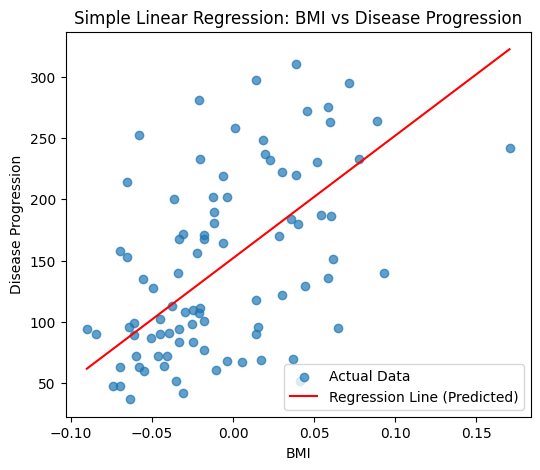

In [321]:
# Ploting the acutal vs predicted values
order = np.argsort(X_test.flatten())
X_test_sorted = X_test.flatten()[order]
y_pred_sorted = y_pred[order]

plt.figure(figsize=(6,5))
plt.scatter(X_test, y_test, alpha=0.7, label="Actual Data")
plt.plot(X_test_sorted, y_pred_sorted, color="red", label="Regression Line (Predicted)")

plt.title("Simple Linear Regression: BMI vs Disease Progression")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.legend(loc="best")
plt.show()

## 3) Multiple Linear Regression

In [322]:
X_all = df[feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred = mlr.predict(X_test)

result_mlr = get_metrics(y_test, y_pred, model_name="Multiple Linear Regression")


--- Multiple Linear Regression ---
MAE : 42.794
MSE : 2900.194
RMSE: 53.853
R^2 : 0.453


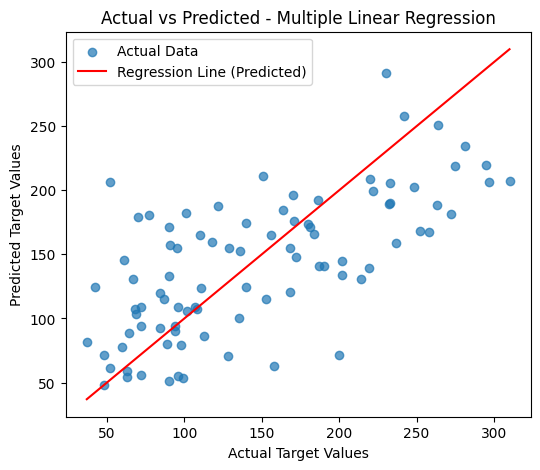

In [323]:
# Plotting the acutal vs predicted values
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.7, label="Actual Data")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", label="Regression Line (Predicted)")

plt.title("Actual vs Predicted - Multiple Linear Regression")
plt.xlabel("Actual Target Values")
plt.ylabel("Predicted Target Values")
plt.legend()
plt.show()

## 4) Polynomial Regression

In [324]:
# Polynomial Regression model with different increasing polynomial degree
feature_name = "bmi"
X_one = df[[feature_name]].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_one, y, test_size=0.2, random_state=42
)

degrees = [1, 2, 3, 4]
poly_results = []
train_r2_list = []
test_r2_list = []

for d in degrees:
    poly_model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("lr", LinearRegression())
    ])

    poly_model.fit(X_train, y_train)

    y_train_pred = poly_model.predict(X_train)
    y_test_pred = poly_model.predict(X_test)

    train_r2_list.append(r2_score(y_train, y_train_pred))
    test_r2_list.append(r2_score(y_test, y_test_pred))

    poly_results.append(get_metrics(y_test, y_test_pred, model_name=f"Polynomial Regression (Degree={d})"))


--- Polynomial Regression (Degree=1) ---
MAE : 52.260
MSE : 4061.826
RMSE: 63.732
R^2 : 0.233

--- Polynomial Regression (Degree=2) ---
MAE : 52.384
MSE : 4085.025
RMSE: 63.914
R^2 : 0.229

--- Polynomial Regression (Degree=3) ---
MAE : 52.181
MSE : 4064.443
RMSE: 63.753
R^2 : 0.233

--- Polynomial Regression (Degree=4) ---
MAE : 52.376
MSE : 4226.145
RMSE: 65.009
R^2 : 0.202


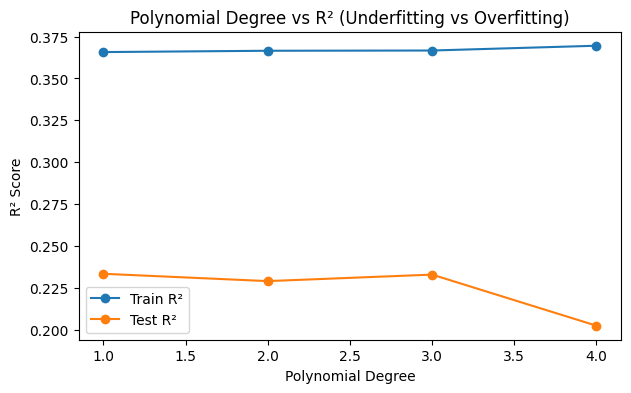

In [325]:
# Plotting polynomial degree vs R2 for displaying overfitting and underfitting performance
plt.figure(figsize=(7,4))
plt.plot(degrees, train_r2_list, marker="o", label="Train R²")
plt.plot(degrees, test_r2_list, marker="o", label="Test R²")
plt.title("Polynomial Degree vs R² (Underfitting vs Overfitting)")
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.legend()
plt.show()

## 5) Regularization with Ridge and Lasso Regression

In [326]:
X_all = df[feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

alphas = [0.01, 0.1, 1, 10]

ridge_metrics = []
lasso_metrics = []

### Ridge Regression

In [327]:
for a in alphas:
    ridge = Ridge(alpha=a, random_state=42)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    ridge_metrics.append(get_metrics(y_test, y_pred, model_name=f"Ridge Regression (alpha={a})"))


--- Ridge Regression (alpha=0.01) ---
MAE : 42.837
MSE : 2882.290
RMSE: 53.687
R^2 : 0.456

--- Ridge Regression (alpha=0.1) ---
MAE : 42.997
MSE : 2856.487
RMSE: 53.446
R^2 : 0.461

--- Ridge Regression (alpha=1) ---
MAE : 46.139
MSE : 3077.416
RMSE: 55.474
R^2 : 0.419

--- Ridge Regression (alpha=10) ---
MAE : 58.031
MSE : 4443.953
RMSE: 66.663
R^2 : 0.161


### Lasso Regression

In [328]:
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000, random_state=42)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    lasso_metrics.append(get_metrics(y_test, y_pred, model_name=f"Lasso Regression (alpha={a})"))


--- Lasso Regression (alpha=0.01) ---
MAE : 42.832
MSE : 2878.559
RMSE: 53.652
R^2 : 0.457

--- Lasso Regression (alpha=0.1) ---
MAE : 42.854
MSE : 2798.193
RMSE: 52.898
R^2 : 0.472

--- Lasso Regression (alpha=1) ---
MAE : 49.730
MSE : 3403.576
RMSE: 58.340
R^2 : 0.358

--- Lasso Regression (alpha=10) ---
MAE : 64.006
MSE : 5361.533
RMSE: 73.222
R^2 : -0.012


### Graph: Ridge vs Lasso Performance

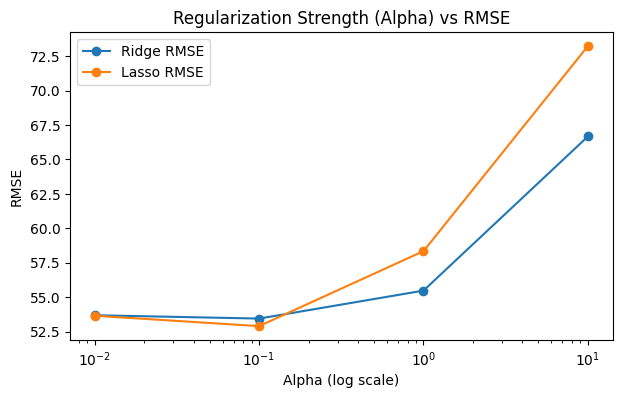

In [329]:
ridge_df = pd.DataFrame(ridge_metrics)
lasso_df = pd.DataFrame(lasso_metrics)
# Plotting the Alpha vs RMSE for Ridge and Lasso comparision
plt.figure(figsize=(7,4))
plt.plot(alphas, ridge_df["RMSE"], marker="o", label="Ridge RMSE")
plt.plot(alphas, lasso_df["RMSE"], marker="o", label="Lasso RMSE")
plt.title("Regularization Strength (Alpha) vs RMSE")
plt.xlabel("Alpha (log scale)")
plt.ylabel("RMSE")
plt.xscale("log")
plt.legend()
plt.show()

In [330]:
alpha_show = 1
# Model comparision based on alpha values
ridge = Ridge(alpha=alpha_show, random_state=42).fit(X_train, y_train)
lasso = Lasso(alpha=alpha_show, max_iter=10000, random_state=42).fit(X_train, y_train)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Ridge_coef": ridge.coef_,
    "Lasso_coef": lasso.coef_
})

coef_df

,Feature,Ridge_coef,Lasso_coef
0,age,45.367377,0.000000
1,sex,-76.666086,-0.000000
2,bmi,291.338832,413.431848
3,bp,198.995817,34.830515
4,s1,-0.530310,0.000000
5,s2,-28.577050,0.000000
6,s3,-144.511905,-0.000000
7,s4,119.260066,0.000000
8,s5,230.221608,258.152894
9,s6,112.149830,0.000000


## 6) Model Comparison and Analysis

In [331]:
# Creating one table for key models
comparison = []

comparison.append(result_slr)
comparison.append(result_mlr)

for r in poly_results:
    if "Degree=2" in r["Model"]:
        comparison.append(r)

# Adding best ridge and best lasso rows
best_ridge_row = ridge_df_sorted.loc[0].to_dict()
best_lasso_row = lasso_df_sorted.loc[0].to_dict()
comparison.append(best_ridge_row)
comparison.append(best_lasso_row)

comparison_df = pd.DataFrame(comparison)

# Sorting by RMSE (lower is better)
comparison_df.sort_values("RMSE")

,Model,MAE,MSE,RMSE,R2
4,Lasso Regression (alpha=0.1),42.854428,2798.193485,52.897954,0.471855
3,Ridge Regression (alpha=0.1),42.996932,2856.486888,53.446112,0.460852
1,Multiple Linear Regression,42.794095,2900.193628,53.853446,0.452603
0,Simple Linear Regression (Feature: bmi),52.259976,4061.825928,63.732456,0.233350
2,Polynomial Regression (Degree=2),52.383912,4085.025481,63.914204,0.228972


## How well each model performed

- Simple Linear Regression did poorer due to the use of only one feature BMI.
- Multiple Linear Regression performed better as it utilized all of the available features.
- Polynomial Regression showed an improvement in model performance at the second degree. However, higher degrees sometimes   resulted in a decrease in test performance.
- Ridge and Lasso Regression performed similarly or slightly better than Multiple Linear Regression.
- Regularized models showed greater stability in terms of their performance when compared to the high-degree polynomial models.

## Which models handled overfitting or improved performance

- Polynomial Regression with a large degree indicated showed for overfitting due to increases in the R² for the training set while decreases in the R² for the test sets.
- Ridge Regression helped to limit the occurrence of overfitting by reducing the magnitude of the coefficients.
- Lasso Regression also limited the occurrence of overfitting and eliminated some of the less influential features.
- The regularized models were more consistent and stable than the high-degree polynomial regression models.


## Insights gained about the Diabetes dataset

- The dataset has several features that together influence the progress of the disease.
- BMI appears to be related to the target variable.
- No missing values were present in the dataset therefore very little data cleaning was required.
- For the most part the relationships between the features and the target are linear, however there are some nonlinear aspects in these relationships.
- Using all of the features together will provide a better prediction of the target variable than using only one feature.